# Movie Rating Prediction — Model Improvement and Feature Analysis

**Notebook:** `04_model_improvement.ipynb`
**Depends on:** `src/data_preprocessing.py` (Phase 2) and the split design of `03_model_training.ipynb` (Phase 3)

## 1. Phase 4 Overview

Phase 3 compared models on **one** 80/20 group split. Gradient Boosting was ahead of Random Forest by an amount
that a bootstrap could not distinguish from zero. Phase 4 asks, using **group-aware cross-validation on the
Phase 3 training rows only**:

1. Do the Phase 3 model differences hold up across folds?
2. Does limited, controlled tuning improve generalisation?
3. Are the preprocessing choices (feature groups, frequency thresholds) reasonable?
4. Which feature groups carry predictive value?
5. Which model and configuration should go into the Phase 5 final evaluation?

**The Phase 3 test set (20%) is not used anywhere in this notebook.** It is recreated only to exclude its rows and is
reserved for Phase 5.

```
modeling rows (7,919)
 ├─ Phase 3 holdout test (1,584 rows)  ── reserved, never touched here
 └─ development set (6,335 rows)
       └─ GroupKFold(5, shuffle, random_state=42) on Name+Year groups
             for each fold: fit preprocessor on fold-train → transform fold-train and fold-validation
                            → fit model on fold-train → predict fold-validation → metrics
```

**Primary features:** `Year`, `Duration`, `Genre`, `Director`, `Actor 1–3`. `Votes` is excluded, and no feature uses
`Rating`.

## 2. Imports and Configuration

In [1]:
import hashlib
import os
import re
import shutil
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "IMDb Movies India.csv"
FIG_DIR = PROJECT_ROOT / "visualizations"
PHASE3_NOTEBOOK = PROJECT_ROOT / "notebooks" / "03_model_training.ipynb"
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))
# Parallel workers (used by the hyperparameter search) must also be able to import the module
os.environ["PYTHONPATH"] = str(SRC_DIR) + os.pathsep + os.environ.get("PYTHONPATH", "")

import data_preprocessing as dp

RANDOM_STATE = 42
TEST_SIZE = 0.20      # Phase 3 holdout definition (must match Phase 3)
N_FOLDS = 5

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 120)

PRIMARY, ACCENT, NEUTRAL, MUTED = "#2a78d6", "#eb6834", "#a3a29c", "#52514e"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": "#c9c8c2", "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "xtick.color": MUTED, "ytick.color": MUTED,
})

DIAG = {}   # diagnostics collected throughout the notebook
NOTEBOOK_START = time.time()

## 3. Load Dataset

In [2]:
PHASE1_SHA256 = "68295a15943a675f38fe8c49af8f5d51b4b833aadb8a4da79da74b0a61c36479"
file_sha256 = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()
assert file_sha256(DATA_PATH) == PHASE1_SHA256, "Raw CSV differs from the Phase 1 version"

raw = dp.load_raw_data(DATA_PATH)  # encoding="latin-1" inside the loader
print(f"Raw data: {raw.shape[0]:,} rows × {raw.shape[1]} columns; checksum matches Phase 1")

Raw data: 15,509 rows × 10 columns; checksum matches Phase 1


## 4. Prepare Modeling Data

`build_modeling_frame` performs only row-wise cleaning and keeps the rated rows (Phase 2). The group key comes from
`dp.make_group_id`, the same normalised `Name + Year` rule used in Phase 3, now shared in the module.

In [3]:
model_df, row_log = dp.build_modeling_frame(raw)
X, y = dp.get_features_and_target(model_df)
groups = dp.make_group_id(model_df)

FORBIDDEN = {"Rating", "Votes", "Votes_eda"}
DIAG["01 Target not among feature inputs"] = dp.TARGET not in X.columns
DIAG["02 Votes absent from primary feature inputs"] = not FORBIDDEN & set(X.columns)
print(f"Modeling rows : {len(X):,}")
print(f"Feature inputs: {list(X.columns)}")
print(f"Groups        : {groups.nunique():,}")

Modeling rows : 7,919
Feature inputs: ['Year', 'Duration_min', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
Groups        : 7,916


## 5. Preserve the Phase 3 Holdout

The Phase 3 split is recreated with **identical** settings (`GroupShuffleSplit`, `test_size=0.2`, `random_state=42`,
same groups). Only its **indices** are kept, to exclude those rows. No holdout features or targets are passed to any
fit, transform, search or metric in this notebook.

In [4]:
holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
dev_idx, holdout_idx = next(holdout_splitter.split(X, y, groups))

X_dev, y_dev, g_dev = X.iloc[dev_idx], y.iloc[dev_idx], groups.iloc[dev_idx]
HOLDOUT_INDEX = X.index[holdout_idx]      # labels only; never used for fitting or scoring
del holdout_idx

print(f"Development rows (Phase 3 training set): {len(X_dev):,} in {g_dev.nunique():,} groups")
print(f"Holdout rows reserved for Phase 5       : {len(HOLDOUT_INDEX):,} in {groups.loc[HOLDOUT_INDEX].nunique():,} groups")
DIAG["03 Phase 3 split reproduced (6,335 / 1,584 rows; 6,332 / 1,584 groups)"] = (
    len(X_dev) == 6335 and len(HOLDOUT_INDEX) == 1584 and g_dev.nunique() == 6332 and groups.loc[HOLDOUT_INDEX].nunique() == 1584)
DIAG["04 Holdout groups disjoint from development groups"] = not set(g_dev) & set(groups.loc[HOLDOUT_INDEX])

Development rows (Phase 3 training set): 6,335 in 6,332 groups
Holdout rows reserved for Phase 5       : 1,584 in 1,584 groups


## 6. Define Group-Aware Cross-Validation

`GroupKFold(n_splits=5, shuffle=True, random_state=42)` places every `Name + Year` group in exactly one validation fold.
With `shuffle=True`, groups are assigned to folds in a seeded random order instead of by size alone.

The fold assignment is computed **once** and reused by every experiment (model comparison, tuning, ablation,
thresholds), so all results are directly comparable.

In [5]:
CV = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(CV.split(X_dev, y_dev, g_dev))
FOLD_SIGNATURE = hashlib.sha256(b"".join(np.sort(va).tobytes() for _, va in FOLDS)).hexdigest()
print(f"{len(FOLDS)} folds; fold signature {FOLD_SIGNATURE[:16]}…")

5 folds; fold signature 9a532ee425b9c36f…


## 7. Verify Fold Group Isolation

In [6]:
fold_rows = []
for k, (tr, va) in enumerate(FOLDS, 1):
    tr_groups, va_groups = set(g_dev.iloc[tr]), set(g_dev.iloc[va])
    fold_rows.append({
        "fold": k, "training rows": len(tr), "validation rows": len(va),
        "training groups": len(tr_groups), "validation groups": len(va_groups),
        "group overlap": len(tr_groups & va_groups),
    })
fold_table = pd.DataFrame(fold_rows).set_index("fold")

all_val = np.concatenate([va for _, va in FOLDS])
DIAG["05 No group overlap in any CV fold"] = (fold_table["group overlap"] == 0).all()
DIAG["06 Fold count correct and every development row validated exactly once"] = (
    len(FOLDS) == N_FOLDS and len(all_val) == len(X_dev) and len(np.unique(all_val)) == len(X_dev))
for k, row in fold_table.iterrows():
    print(f"Fold {k}: intersection(train_groups, validation_groups) = "
          f"{'set()  (empty)' if row['group overlap'] == 0 else row['group overlap']}")
fold_table

Fold 1: intersection(train_groups, validation_groups) = set()  (empty)
Fold 2: intersection(train_groups, validation_groups) = set()  (empty)
Fold 3: intersection(train_groups, validation_groups) = set()  (empty)
Fold 4: intersection(train_groups, validation_groups) = set()  (empty)
Fold 5: intersection(train_groups, validation_groups) = set()  (empty)


,training rows,validation rows,training groups,validation groups,group overlap
fold,,,,,
1,5068,1267,5065,1267,0
2,5068,1267,5065,1267,0
3,5068,1267,5066,1266,0
4,5068,1267,5066,1266,0
5,5068,1267,5066,1266,0


### Cross-validation machinery

`get_fold_matrices` implements the leakage-safe workflow **for every fold**:

1. take fold-train and fold-validation rows from the development set
2. build a **fresh, unfitted** transformer with `dp.build_feature_transformer(...)`
3. `fit` it on fold-train only
4. transform fold-train and fold-validation with that fitted object

The transformed matrices depend only on the preprocessing configuration, not on the model. They are therefore
computed once per configuration and shared by all models evaluated with it. Each model is then fitted on the
fold-train matrix and scored on the fold-validation matrix (`run_cv`).

For every fold the function also verifies:
- the learned director and actor counts equal counts computed by hand from fold-train alone
- validation-only names are absent from them
- there are no NaN or infinite values, and the columns match

In [7]:
_FOLD_CACHE = {}
FOLD_CHECKS = []

def _people_counts(frame, cols):
    names = frame[cols].apply(lambda r: {v for v in r.dropna()}, axis=1).explode().dropna()
    return names.value_counts().to_dict()

def get_fold_matrices(director_min_count=10, actor_min_count=20, feature_groups=dp.FEATURE_GROUPS):
    key = (director_min_count, actor_min_count, tuple(feature_groups))
    if key in _FOLD_CACHE:
        return _FOLD_CACHE[key]
    folds = []
    for k, (tr, va) in enumerate(FOLDS, 1):
        X_tr, X_va = X_dev.iloc[tr], X_dev.iloc[va]
        pre = dp.build_feature_transformer(director_min_count, actor_min_count, feature_groups).fit(X_tr)
        Xt_tr, Xt_va = pre.transform(X_tr), pre.transform(X_va)

        check = {"config": key, "fold": k}
        steps = dict((n, s) for n, s, _ in pre.transformers_)
        if "director" in steps:
            check["director counts from fold-train only"] = steps["director"].name_counts_ == _people_counts(X_tr, ["Director"])
            check["validation-only directors absent"] = not (
                (set(X_va["Director"].dropna()) - set(X_tr["Director"].dropna())) & set(steps["director"].name_counts_))
        if "actors" in steps:
            check["actor counts from fold-train only"] = steps["actors"].name_counts_ == _people_counts(X_tr, dp.ACTOR_COLUMNS)
        if "numeric" in steps:
            check["duration median from fold-train only"] = (
                steps["numeric"].duration_median_ == float(pd.to_numeric(X_tr["Duration_min"], errors="coerce").median()))
        A, B = Xt_tr.to_numpy(dtype=float), Xt_va.to_numpy(dtype=float)
        check["no NaN"] = not (np.isnan(A).any() or np.isnan(B).any())
        check["no inf"] = np.isfinite(A).all() and np.isfinite(B).all()
        check["columns match"] = list(Xt_tr.columns) == list(Xt_va.columns)
        FOLD_CHECKS.append(check)
        folds.append({"tr": tr, "va": va, "Xt_tr": Xt_tr, "Xt_va": Xt_va, "pre": pre})
    _FOLD_CACHE[key] = folds
    return folds


def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred), "MSE": mse, "RMSE": float(np.sqrt(mse)), "R²": r2_score(y_true, y_pred)}


_RUN_CACHE = {}

def _fit_fold(model, Xt_tr, y_tr, Xt_va):
    est = clone(model).fit(Xt_tr, y_tr)
    return est, est.predict(Xt_va), est.predict(Xt_tr)

def run_cv(model, label, **prep_config):
    """Fit a clone of `model` on each fold-train matrix and score it on the fold-validation matrix.

    The folds are independent, so they are fitted in parallel worker processes (results are identical
    to a sequential loop; each worker receives only that fold's matrices). An experiment with exactly the same model parameters and preprocessing
    configuration as an earlier one is reused instead of refitted.
    """
    key = (type(model).__name__, repr(sorted(model.get_params().items())), tuple(sorted(prep_config.items())))
    if key in _RUN_CACHE:
        prev = _RUN_CACHE[key]
        return {**prev, "label": label, "per_fold": prev["per_fold"].assign(model=label), "reused_from": prev["label"]}

    folds = get_fold_matrices(**prep_config)
    fold_results = Parallel(n_jobs=len(folds))(
        delayed(_fit_fold)(model, f["Xt_tr"], y_dev.iloc[f["tr"]], f["Xt_va"]) for f in folds)
    oof = pd.Series(np.nan, index=X_dev.index)
    rows, fitted = [], []
    for k, (f, (est, pred_va, pred_tr)) in enumerate(zip(folds, fold_results), 1):
        y_tr, y_va = y_dev.iloc[f["tr"]], y_dev.iloc[f["va"]]
        assert len(pred_va) == len(y_va)
        oof.iloc[f["va"]] = pred_va
        m_va, m_tr = metrics(y_va, pred_va), metrics(y_tr, pred_tr)
        rows.append({"model": label, "fold": k, **m_va, "train RMSE": m_tr["RMSE"], "train R²": m_tr["R²"],
                     "n_features": f["Xt_tr"].shape[1]})
        fitted.append(est)
    result = {"label": label, "per_fold": pd.DataFrame(rows), "oof": oof, "models": fitted,
              "config": prep_config, "fold_signature": FOLD_SIGNATURE}
    _RUN_CACHE[key] = result
    return result


def summarise(results):
    out = []
    for r in results:
        pf = r["per_fold"]
        row = {"model": r["label"]}
        for m in ["MAE", "MSE", "RMSE", "R²"]:
            row[f"{m} mean"], row[f"{m} std"] = pf[m].mean(), pf[m].std(ddof=1)
        row["train RMSE mean"] = pf["train RMSE"].mean()
        row["train−val RMSE gap"] = pf["RMSE"].mean() - pf["train RMSE"].mean()
        out.append(row)
    return pd.DataFrame(out).set_index("model")

CV_RUNS = {}

## 8. Cross-Validation — Baseline

In each fold the baseline predicts the **mean rating of that fold's training rows** (`DummyRegressor(strategy="mean")`).

In [8]:
CV_RUNS["Baseline (fold-train mean)"] = run_cv(DummyRegressor(strategy="mean"), "Baseline (fold-train mean)")
baseline_check = all(
    np.isclose(m.constant_[0][0], y_dev.iloc[f["tr"]].mean())
    for m, f in zip(CV_RUNS["Baseline (fold-train mean)"]["models"], get_fold_matrices()))
DIAG["07 Baseline uses each fold's training mean (not a global mean)"] = baseline_check
CV_RUNS["Baseline (fold-train mean)"]["per_fold"].round(4)

,model,fold,MAE,MSE,RMSE,R²,train RMSE,train R²,n_features
0,Baseline (fold-train mean),1,1.1031,1.8548,1.3619,-0.0002,1.3836,0.0,239
1,Baseline (fold-train mean),2,1.1731,2.0385,1.4277,-0.0000,1.3669,0.0,244
2,Baseline (fold-train mean),3,1.1056,1.8206,1.3493,-0.0009,1.3867,0.0,237
3,Baseline (fold-train mean),4,1.1331,1.9453,1.3947,-0.0025,1.3755,0.0,246
4,Baseline (fold-train mean),5,1.1062,1.8580,1.3631,-0.0043,1.3834,0.0,243


## 9. Cross-Validation — Linear Regression

This is the same pipeline as Phase 3: `StandardScaler` → `LinearRegression`. The scaler is part of the estimator, so
it is refitted on each fold's training matrix.

In [9]:
CV_RUNS["Linear Regression"] = run_cv(make_pipeline(StandardScaler(), LinearRegression()), "Linear Regression")
CV_RUNS["Linear Regression"]["per_fold"].round(4)

,model,fold,MAE,MSE,RMSE,R²,train RMSE,train R²,n_features
0,Linear Regression,1,0.9473,1.4561,1.2067,0.2148,1.1816,0.2707,239
1,Linear Regression,2,0.9891,1.5829,1.2582,0.2235,1.1675,0.2705,244
2,Linear Regression,3,0.9449,1.4389,1.1995,0.2090,1.1838,0.2712,237
3,Linear Regression,4,0.9712,1.5259,1.2353,0.2137,1.1744,0.2710,246
4,Linear Regression,5,0.9597,1.4793,1.2163,0.2004,1.1815,0.2706,243


## 10. Cross-Validation — Random Forest (Phase 3 parameters)

In [10]:
RF_PHASE3 = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33, n_jobs=-1,
                                  random_state=RANDOM_STATE)
CV_RUNS["Random Forest"] = run_cv(RF_PHASE3, "Random Forest")
CV_RUNS["Random Forest"]["per_fold"].round(4)

,model,fold,MAE,MSE,RMSE,R²,train RMSE,train R²,n_features
0,Random Forest,1,0.9038,1.3390,1.1572,0.2779,0.7945,0.6703,239
1,Random Forest,2,0.9488,1.4873,1.2195,0.2704,0.7809,0.6736,244
2,Random Forest,3,0.8924,1.3062,1.1429,0.2819,0.8007,0.6666,237
3,Random Forest,4,0.9326,1.4402,1.2001,0.2578,0.7822,0.6766,246
4,Random Forest,5,0.9057,1.3150,1.1467,0.2892,0.7939,0.6707,243


## 11. Cross-Validation — Gradient Boosting (Phase 3 parameters)

In [11]:
GB_PHASE3 = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
CV_RUNS["Gradient Boosting"] = run_cv(GB_PHASE3, "Gradient Boosting")
CV_RUNS["Gradient Boosting"]["per_fold"].round(4)

,model,fold,MAE,MSE,RMSE,R²,train RMSE,train R²,n_features
0,Gradient Boosting,1,0.9033,1.3402,1.1577,0.2773,1.1104,0.3559,239
1,Gradient Boosting,2,0.9570,1.4931,1.2219,0.2675,1.0927,0.3609,244
2,Gradient Boosting,3,0.8949,1.3198,1.1488,0.2745,1.1134,0.3553,237
3,Gradient Boosting,4,0.9321,1.4321,1.1967,0.2620,1.0971,0.3638,246
4,Gradient Boosting,5,0.9194,1.3346,1.1553,0.2786,1.1090,0.3574,243


**Equivalence check with a standard sklearn Pipeline.** The same Random Forest is evaluated with
`cross_validate(Pipeline([preprocessor, model]), groups=...)`, where sklearn itself refits the preprocessor inside
each fold. The per-fold scores must match the manual loop exactly.

In [12]:
pipe_rf = Pipeline([("prep", dp.build_feature_transformer()), ("model", clone(RF_PHASE3))])
sk_cv = cross_validate(pipe_rf, X_dev, y_dev, groups=g_dev, cv=CV, scoring="neg_root_mean_squared_error")
manual_rmse = CV_RUNS["Random Forest"]["per_fold"]["RMSE"].to_numpy()
print("sklearn Pipeline fold RMSE:", np.round(-sk_cv["test_score"], 6))
print("manual loop fold RMSE     :", np.round(manual_rmse, 6))
DIAG["08 Manual fold loop reproduces sklearn Pipeline cross_validate"] = np.allclose(-sk_cv["test_score"], manual_rmse)

sklearn Pipeline fold RMSE: [1.15716  1.21955  1.142897 1.200078 1.146734]
manual loop fold RMSE     : [1.15716  1.21955  1.142897 1.200078 1.146734]


## 12. CV Model Comparison

In [13]:
BASE_MODELS = ["Baseline (fold-train mean)", "Linear Regression", "Random Forest", "Gradient Boosting"]
cv_summary = summarise([CV_RUNS[m] for m in BASE_MODELS]).sort_values("RMSE mean")
cv_summary[["MAE mean", "MAE std", "MSE mean", "MSE std", "RMSE mean", "RMSE std", "R² mean", "R² std"]].round(4)

,MAE mean,MAE std,MSE mean,MSE std,RMSE mean,RMSE std,R² mean,R² std
model,,,,,,,,
Random Forest,0.9167,0.0233,1.3775,0.0813,1.1733,0.0344,0.2755,0.0120
Gradient Boosting,0.9213,0.0246,1.3840,0.0753,1.1761,0.0318,0.2720,0.0070
Linear Regression,0.9624,0.0182,1.4966,0.0583,1.2232,0.0237,0.2123,0.0084
Baseline (fold-train mean),1.1242,0.0299,1.9034,0.0884,1.3794,0.0318,-0.0016,0.0018


In [14]:
def paired_fold_comparison(names, reference):
    ref = CV_RUNS[reference]["per_fold"].set_index("fold")["RMSE"]
    rows = []
    for n in names:
        if n == reference:
            continue
        diff = CV_RUNS[n]["per_fold"].set_index("fold")["RMSE"] - ref
        rows.append({"model": n, f"mean RMSE diff vs {reference}": diff.mean(), "std of fold diffs": diff.std(ddof=1),
                     "folds where model is better": int((diff < 0).sum()), "folds where model is worse": int((diff > 0).sum())})
    return pd.DataFrame(rows).set_index("model")

ref_base = cv_summary.index[0]
print(f"Reference = lowest mean CV RMSE among untuned models: {ref_base}")
paired_fold_comparison(BASE_MODELS, ref_base).round(4)

Reference = lowest mean CV RMSE among untuned models: Random Forest


,mean RMSE diff vs Random Forest,std of fold diffs,folds where model is better,folds where model is worse
model,,,,
Baseline (fold-train mean),0.2061,0.0078,0,5
Linear Regression,0.0499,0.0139,0,5
Gradient Boosting,0.0028,0.0046,1,4


The paired comparison uses the **same folds** for every model, so per-fold differences remove the part of the
variation that comes from some folds simply being harder than others. A model is only treated as clearly better if it
wins consistently across folds, with a mean difference larger than the fold-to-fold noise.

In [15]:
per_fold_all = pd.concat([CV_RUNS[m]["per_fold"] for m in BASE_MODELS])
print("Validation RMSE per fold:")
per_fold_all.pivot(index="fold", columns="model", values="RMSE")[BASE_MODELS].round(4)

Validation RMSE per fold:


model,Baseline (fold-train mean),Linear Regression,Random Forest,Gradient Boosting
fold,,,,
1,1.3619,1.2067,1.1572,1.1577
2,1.4277,1.2582,1.2195,1.2219
3,1.3493,1.1995,1.1429,1.1488
4,1.3947,1.2353,1.2001,1.1967
5,1.3631,1.2163,1.1467,1.1553


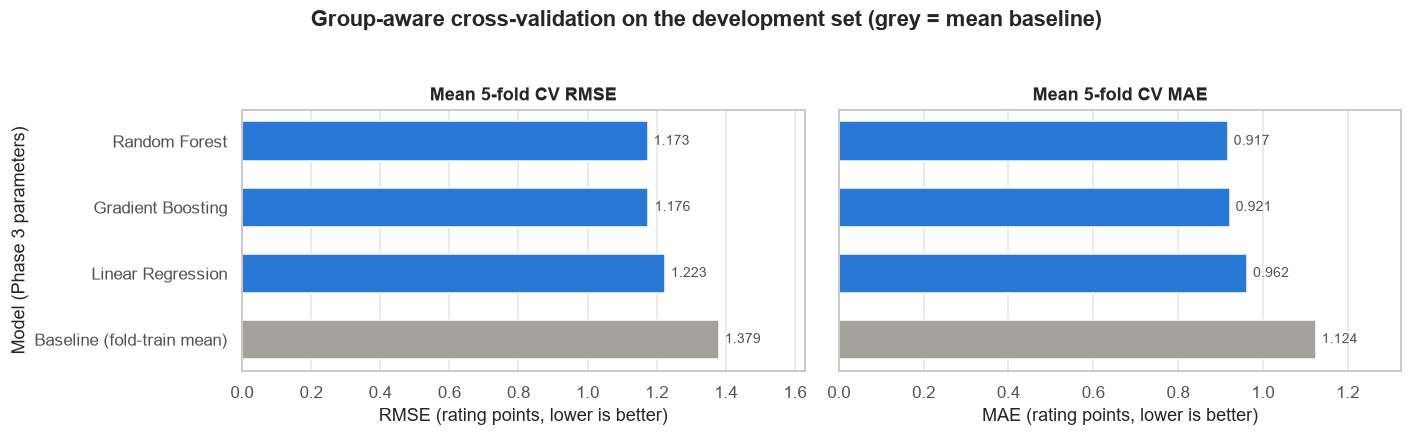

In [16]:
# 12_cv_model_comparison.png — mean CV RMSE and MAE per model
order = cv_summary.index.tolist()[::-1]
colors = [NEUTRAL if n.startswith("Baseline") else PRIMARY for n in order]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, m in zip(axes, ["RMSE", "MAE"]):
    vals = cv_summary.loc[order, f"{m} mean"]
    bars = ax.barh(order, vals, color=colors, height=0.6)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=4, fontsize=9, color=MUTED)
    ax.set_xlim(0, vals.max() * 1.18)
    ax.set_title(f"Mean {N_FOLDS}-fold CV {m}")
    ax.set_xlabel(f"{m} (rating points, lower is better)")
    ax.grid(axis="y", visible=False)
axes[0].set_ylabel("Model (Phase 3 parameters)")
fig.suptitle("Group-aware cross-validation on the development set (grey = mean baseline)", fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_cv_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Controlled Hyperparameter Search

Only the two tree ensembles are tuned. The search is deliberately small:

- `RandomizedSearchCV` with **12** sampled Gradient Boosting and **10** sampled Random Forest configurations
- the **same group-aware folds** (`cv=CV`, `groups=g_dev`), on the development set only
- scoring: `neg_root_mean_squared_error`, i.e. RMSE, the primary metric, which penalises large errors

The estimator is a `Pipeline([preprocessor, model])`, so sklearn refits the preprocessor inside every fold.
`memory=` caches the fitted preprocessor per fold, which avoids refitting identical preprocessing for every candidate.
Preprocessing thresholds stay at the Phase 2 defaults here; they are examined separately in Section 16.

| Model | Parameter | Values | Why |
|---|---|---|---|
| Gradient Boosting | `n_estimators` | 200, 400, 600 | number of boosting steps |
| | `learning_rate` | 0.02, 0.05, 0.1 | step size (trade-off with `n_estimators`) |
| | `max_depth` | 2, 3, 4 | interaction depth of each tree |
| | `min_samples_leaf` | 1, 10, 30 | smoothing of leaf estimates |
| | `subsample` | 0.8, 1.0 | stochastic boosting (row sampling) |
| Random Forest | `n_estimators` | 300, 500 | ensemble size |
| | `max_depth` | None, 15, 30 | tree depth limit |
| | `min_samples_leaf` | 1, 3, 5, 10 | smoothing / overfitting control |
| | `max_features` | 0.2, 0.33, 0.5, 1.0 | feature subsampling per split |

In [17]:
GB_SPACE = {
    "model__n_estimators": [200, 400, 600],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 10, 30],
    "model__subsample": [0.8, 1.0],
}
RF_SPACE = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 15, 30],
    "model__min_samples_leaf": [1, 3, 5, 10],
    "model__max_features": [0.2, 0.33, 0.5, 1.0],
}
CACHE_DIR = tempfile.mkdtemp(prefix="phase4_prep_cache_")

def make_search(model, space, n_iter):
    pipe = Pipeline([("prep", dp.build_feature_transformer()), ("model", model)], memory=CACHE_DIR)
    return RandomizedSearchCV(pipe, space, n_iter=n_iter, scoring="neg_root_mean_squared_error", cv=CV,
                              random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True, refit=False)

searches = {}
for name, model, space, n_iter in [
    ("Gradient Boosting", GradientBoostingRegressor(random_state=RANDOM_STATE), GB_SPACE, 12),
    ("Random Forest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), RF_SPACE, 10),
]:
    t0 = time.time()
    searches[name] = make_search(model, space, n_iter).fit(X_dev, y_dev, groups=g_dev)
    print(f"{name}: {n_iter} candidates × {N_FOLDS} folds in {time.time() - t0:.0f}s")

Gradient Boosting: 12 candidates × 5 folds in 68s


Random Forest: 10 candidates × 5 folds in 63s


In [18]:
def search_table(search):
    res = pd.DataFrame(search.cv_results_)
    params = pd.json_normalize(res["params"]).rename(columns=lambda c: c.replace("model__", ""))
    out = params.assign(**{
        "CV RMSE mean": -res["mean_test_score"], "CV RMSE std": res["std_test_score"],
        "train RMSE mean": -res["mean_train_score"],
    })
    out["train−val gap"] = out["CV RMSE mean"] - out["train RMSE mean"]
    return out.sort_values("CV RMSE mean").reset_index(drop=True)

for name, s in searches.items():
    print(f"\n{name} — candidates ranked by mean CV RMSE")
    display(search_table(s).round(4))


Gradient Boosting — candidates ranked by mean CV RMSE


,subsample,n_estimators,min_samples_leaf,max_depth,learning_rate,CV RMSE mean,CV RMSE std,train RMSE mean,train−val gap
0,0.8,600,10,4,0.05,1.1549,0.0324,0.9915,0.1634
1,1.0,600,10,4,0.05,1.1596,0.0317,1.0326,0.1270
2,0.8,200,1,4,0.10,1.1677,0.0269,0.9903,0.1774
3,0.8,400,30,4,0.10,1.1735,0.0365,0.9788,0.1947
4,0.8,600,1,4,0.05,1.1753,0.0324,0.9290,0.2463
5,1.0,600,1,3,0.10,1.1780,0.0297,0.9688,0.2091
6,1.0,400,30,4,0.02,1.1805,0.0294,1.1299,0.0506
7,1.0,600,10,3,0.02,1.1807,0.0294,1.1333,0.0474
8,0.8,200,30,3,0.05,1.1822,0.0289,1.1395,0.0428
9,1.0,200,1,2,0.10,1.1852,0.0277,1.1399,0.0453



Random Forest — candidates ranked by mean CV RMSE


,n_estimators,min_samples_leaf,max_features,max_depth,CV RMSE mean,CV RMSE std,train RMSE mean,train−val gap
0,300,3,0.33,NaN,1.1733,0.0308,0.7904,0.3828
1,300,3,0.33,15.0,1.1756,0.0307,0.9091,0.2665
2,500,5,0.33,30.0,1.1759,0.0302,0.9194,0.2564
3,300,1,0.20,NaN,1.1770,0.0298,0.4340,0.7430
4,500,1,0.20,15.0,1.1775,0.0296,0.8812,0.2963
5,500,5,0.20,30.0,1.1776,0.0285,0.9894,0.1882
6,500,1,0.33,30.0,1.1782,0.0335,0.4525,0.7258
7,500,10,0.33,30.0,1.1834,0.0294,1.0417,0.1417
8,300,1,0.50,30.0,1.1849,0.0352,0.4509,0.7339
9,300,10,1.00,30.0,1.1879,0.0350,0.9883,0.1996


In [19]:
best_params = {name: {k.replace("model__", ""): v for k, v in s.best_params_.items()} for name, s in searches.items()}
for name, p in best_params.items():
    print(f"{name} best sampled configuration: {p}  (mean CV RMSE {-searches[name].best_score_:.4f})")

search_splits_equal = all(
    all(np.array_equal(va, fva) for (_, va), (_, fva) in zip(s.cv.split(X_dev, y_dev, g_dev), FOLDS))
    for s in searches.values())
DIAG["09 Hyperparameter search used the same group-aware folds (GroupKFold with groups)"] = (
    search_splits_equal and all(isinstance(s.cv, GroupKFold) for s in searches.values()))
print("\nIs any best value at the edge of its searched range?")
for name, space in [("Gradient Boosting", GB_SPACE), ("Random Forest", RF_SPACE)]:
    for k, values in space.items():
        v = searches[name].best_params_[k]
        numeric = [x for x in values if x is not None]
        edge = v is not None and len(numeric) > 2 and v in (min(numeric), max(numeric))  # 2-value choices have no interior
        print(f"  {name:<18} {k.replace('model__', ''):<17} best = {str(v):<5} searched {values}  {'<- at edge' if edge else ''}")
print("\nBest Random Forest configuration equals the Phase 3 parameters:",
      best_params["Random Forest"] == {"n_estimators": 300, "min_samples_leaf": 3, "max_features": 0.33, "max_depth": None})

DIAG["10 Search fitted on development rows only (no holdout rows)"] = all(
    s.n_splits_ == N_FOLDS for s in searches.values()) and not set(X_dev.index) & set(HOLDOUT_INDEX)

Gradient Boosting best sampled configuration: {'subsample': 0.8, 'n_estimators': 600, 'min_samples_leaf': 10, 'max_depth': 4, 'learning_rate': 0.05}  (mean CV RMSE 1.1549)
Random Forest best sampled configuration: {'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 0.33, 'max_depth': None}  (mean CV RMSE 1.1733)



Is any best value at the edge of its searched range?
  Gradient Boosting  n_estimators      best = 600   searched [200, 400, 600]  <- at edge
  Gradient Boosting  learning_rate     best = 0.05  searched [0.02, 0.05, 0.1]  
  Gradient Boosting  max_depth         best = 4     searched [2, 3, 4]  <- at edge
  Gradient Boosting  min_samples_leaf  best = 10    searched [1, 10, 30]  
  Gradient Boosting  subsample         best = 0.8   searched [0.8, 1.0]  
  Random Forest      n_estimators      best = 300   searched [300, 500]  
  Random Forest      max_depth         best = None  searched [None, 15, 30]  
  Random Forest      min_samples_leaf  best = 3     searched [1, 3, 5, 10]  
  Random Forest      max_features      best = 0.33  searched [0.2, 0.33, 0.5, 1.0]  

Best Random Forest configuration equals the Phase 3 parameters: True


**Caveat about selection bias.** The best configuration was chosen using the same folds on which it is evaluated
below, so its CV score is slightly **optimistic**. Nested CV would remove this bias but is not used here, to keep
computation reasonable. The untouched Phase 3 holdout will give the unbiased estimate in Phase 5.

The best Gradient Boosting configuration is compared with the edges of its search range in the summary. A best value
at the edge of a range means a larger range might do better; this is recorded as a limitation, not chased further.

## 14. Tuned Model Cross-Validation

In [20]:
GB_TUNED = GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params["Gradient Boosting"])
RF_TUNED = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params["Random Forest"])

CV_RUNS["Gradient Boosting (tuned)"] = run_cv(GB_TUNED, "Gradient Boosting (tuned)")
CV_RUNS["Random Forest (tuned)"] = run_cv(RF_TUNED, "Random Forest (tuned)")

DIAG["11 Manual CV of tuned models reproduces search scores"] = all(
    np.isclose(CV_RUNS[f"{n} (tuned)"]["per_fold"]["RMSE"].mean(), -searches[n].best_score_) for n in searches)

ALL_MODELS = BASE_MODELS + ["Random Forest (tuned)", "Gradient Boosting (tuned)"]
full_summary = summarise([CV_RUNS[m] for m in ALL_MODELS]).sort_values("RMSE mean")
full_summary.round(4)

,MAE mean,MAE std,MSE mean,MSE std,RMSE mean,RMSE std,R² mean,R² std,train RMSE mean,train−val RMSE gap
model,,,,,,,,,,
Gradient Boosting (tuned),0.9009,0.0256,1.3348,0.0845,1.1549,0.0363,0.2980,0.0126,0.9915,0.1634
Random Forest,0.9167,0.0233,1.3775,0.0813,1.1733,0.0344,0.2755,0.0120,0.7904,0.3828
Random Forest (tuned),0.9167,0.0233,1.3775,0.0813,1.1733,0.0344,0.2755,0.0120,0.7904,0.3828
Gradient Boosting,0.9213,0.0246,1.3840,0.0753,1.1761,0.0318,0.2720,0.0070,1.1045,0.0716
Linear Regression,0.9624,0.0182,1.4966,0.0583,1.2232,0.0237,0.2123,0.0084,1.1778,0.0454
Baseline (fold-train mean),1.1242,0.0299,1.9034,0.0884,1.3794,0.0318,-0.0016,0.0018,1.3792,0.0002


In [21]:
ref_all = full_summary.index[0]
print(f"Reference = lowest mean CV RMSE overall: {ref_all}")
paired_all = paired_fold_comparison(ALL_MODELS, ref_all)
paired_all.round(4)

Reference = lowest mean CV RMSE overall: Gradient Boosting (tuned)


,mean RMSE diff vs Gradient Boosting (tuned),std of fold diffs,folds where model is better,folds where model is worse
model,,,,
Baseline (fold-train mean),0.2245,0.0076,0,5
Linear Regression,0.0683,0.0156,0,5
Random Forest,0.0184,0.0067,0,5
Gradient Boosting,0.0212,0.0072,0,5
Random Forest (tuned),0.0184,0.0067,0,5


In [22]:
print("Validation RMSE per fold, all models:")
pd.concat([CV_RUNS[m]["per_fold"] for m in ALL_MODELS]).pivot(index="fold", columns="model", values="RMSE")[ALL_MODELS].round(4)

Validation RMSE per fold, all models:


model,Baseline (fold-train mean),Linear Regression,Random Forest,Gradient Boosting,Random Forest (tuned),Gradient Boosting (tuned)
fold,,,,,,
1,1.3619,1.2067,1.1572,1.1577,1.1572,1.1429
2,1.4277,1.2582,1.2195,1.2219,1.2195,1.2095
3,1.3493,1.1995,1.1429,1.1488,1.1429,1.1234
4,1.3947,1.2353,1.2001,1.1967,1.2001,1.1725
5,1.3631,1.2163,1.1467,1.1553,1.1467,1.1261


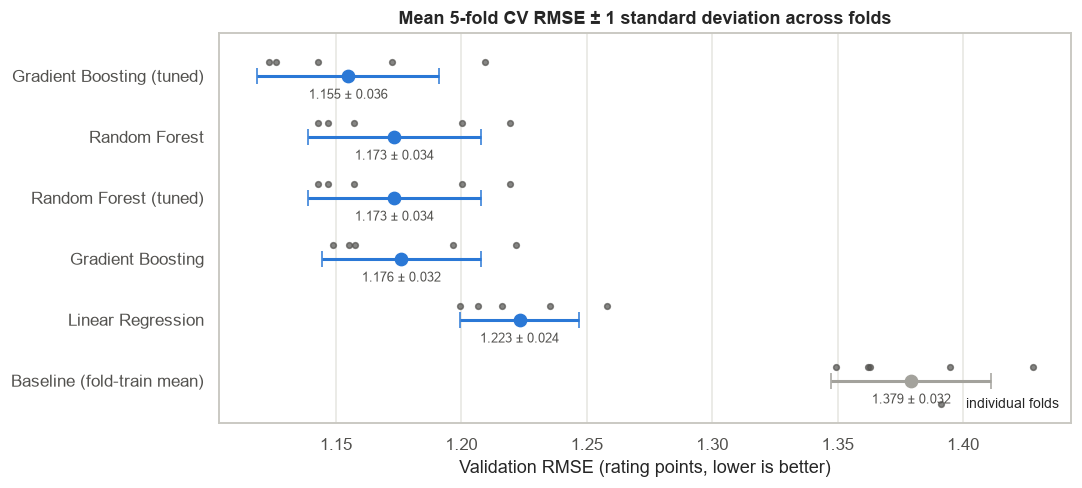

In [23]:
# 13_cv_error_bars.png — mean CV RMSE ± 1 std across folds, with individual fold scores
order = full_summary.index.tolist()[::-1]
fig, ax = plt.subplots(figsize=(10, 4.6))
for i, name in enumerate(order):
    pf = CV_RUNS[name]["per_fold"]["RMSE"]
    color = NEUTRAL if name.startswith("Baseline") else PRIMARY
    ax.errorbar(pf.mean(), i, xerr=pf.std(ddof=1), fmt="o", color=color, ecolor=color, elinewidth=2, capsize=5,
                markersize=8, zorder=3)
    ax.scatter(pf, np.full(len(pf), i + 0.22), s=14, color=MUTED, alpha=0.7, zorder=2,
               label="individual folds" if i == 0 else None)
    ax.annotate(f"{pf.mean():.3f} ± {pf.std(ddof=1):.3f}", (pf.mean(), i), xytext=(0, -15),
                textcoords="offset points", ha="center", fontsize=8.5, color=MUTED)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_xlabel("Validation RMSE (rating points, lower is better)")
ax.set_title(f"Mean {N_FOLDS}-fold CV RMSE ± 1 standard deviation across folds")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_cv_error_bars.png", dpi=120, bbox_inches="tight")
plt.show()

## 15. Feature Group Ablation

Feature groups are added **one at a time**. The model, folds and thresholds stay fixed, so each step changes only the
feature set. The model used is the **tuned tree model with the lowest mean CV RMSE** (selected in code below). The
preprocessor is still fitted inside each fold for every configuration.

| Config | Feature groups |
|---|---|
| A | Year + Duration |
| B | A + Genre |
| C | B + Director |
| D | C + Actors (full primary feature set) |

In [24]:
tuned_trees = ["Gradient Boosting (tuned)", "Random Forest (tuned)"]
ANALYSIS_MODEL_NAME = min(tuned_trees, key=lambda n: full_summary.loc[n, "RMSE mean"])
ANALYSIS_MODEL = GB_TUNED if ANALYSIS_MODEL_NAME.startswith("Gradient") else RF_TUNED
print(f"Model used for ablation, threshold analysis and importance: {ANALYSIS_MODEL_NAME}")

ABLATION = {
    "A: Year + Duration": ("numeric",),
    "B: + Genre": ("numeric", "genre"),
    "C: + Director": ("numeric", "genre", "director"),
    "D: + Actors (full)": ("numeric", "genre", "director", "actors"),
}
ablation_runs = {}
for label, fg in ABLATION.items():
    ablation_runs[label] = run_cv(ANALYSIS_MODEL, label, feature_groups=fg)

ablation_summary = summarise(ablation_runs.values())
ablation_summary.insert(0, "features", [ablation_runs[l]["per_fold"]["n_features"].iloc[0] for l in ablation_summary.index])
ablation_summary["ΔRMSE vs previous"] = ablation_summary["RMSE mean"].diff()
ablation_summary[["features", "MAE mean", "RMSE mean", "RMSE std", "R² mean", "ΔRMSE vs previous"]].round(4)

Model used for ablation, threshold analysis and importance: Gradient Boosting (tuned)


,features,MAE mean,RMSE mean,RMSE std,R² mean,ΔRMSE vs previous
model,,,,,,
A: Year + Duration,3,1.0065,1.2839,0.0338,0.1323,NaN
B: + Genre,27,0.9489,1.2106,0.0323,0.2285,-0.0732
C: + Director,98,0.9282,1.1843,0.0345,0.2618,-0.0263
D: + Actors (full),239,0.9009,1.1549,0.0363,0.2980,-0.0294


In [25]:
abl_labels = list(ABLATION)
step_diffs = []
for prev, cur in zip(abl_labels, abl_labels[1:]):
    d = ablation_runs[cur]["per_fold"]["RMSE"].to_numpy() - ablation_runs[prev]["per_fold"]["RMSE"].to_numpy()
    step_diffs.append({"step": f"{prev.split(':')[0]} → {cur.split(':')[0]}", "mean ΔRMSE": d.mean(),
                       "std of fold Δ": d.std(ddof=1), "folds improved": int((d < 0).sum())})
pd.DataFrame(step_diffs).set_index("step").round(4)

,mean ΔRMSE,std of fold Δ,folds improved
step,,,
A → B,-0.0732,0.0161,5
B → C,-0.0263,0.0036,5
C → D,-0.0294,0.0104,5


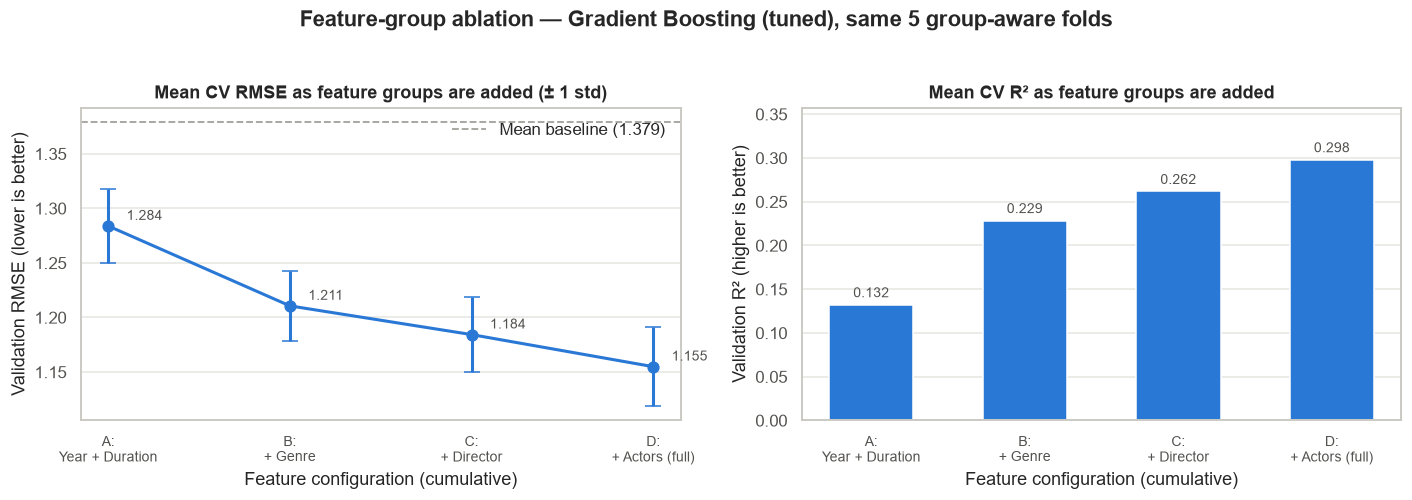

In [26]:
# 14_feature_group_ablation.png
labels = [l.replace(": ", ":\n") for l in ablation_summary.index]
means, stds = ablation_summary["RMSE mean"], ablation_summary["RMSE std"]
base_rmse = full_summary.loc["Baseline (fold-train mean)", "RMSE mean"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].errorbar(range(len(means)), means, yerr=stds, fmt="-o", color=PRIMARY, capsize=5, linewidth=2, markersize=7)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].annotate(f"{m:.3f}", (i, m), xytext=(12, 4), textcoords="offset points", fontsize=9, color=MUTED)
axes[0].axhline(base_rmse, color=NEUTRAL, linestyle="--", linewidth=1.2, label=f"Mean baseline ({base_rmse:.3f})")
axes[0].set_title("Mean CV RMSE as feature groups are added (± 1 std)")
axes[0].set_ylabel("Validation RMSE (lower is better)")
axes[0].legend(frameon=False, loc="upper right")
r2 = ablation_summary["R² mean"]
bars = axes[1].bar(range(len(r2)), r2, color=PRIMARY, width=0.55)
axes[1].bar_label(bars, labels=[f"{v:.3f}" for v in r2], padding=3, fontsize=9, color=MUTED)
axes[1].set_title("Mean CV R² as feature groups are added")
axes[1].set_ylabel("Validation R² (higher is better)")
axes[1].set_ylim(0, r2.max() * 1.2)
for ax in axes:
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Feature configuration (cumulative)")
    ax.grid(axis="x", visible=False)
fig.suptitle(f"Feature-group ablation — {ANALYSIS_MODEL_NAME}, same {N_FOLDS} group-aware folds",
             fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "14_feature_group_ablation.png", dpi=120, bbox_inches="tight")
plt.show()

## 16. Director / Actor Threshold Analysis

The Phase 2 thresholds decide which directors (≥ 10 training films) and actors (≥ 20) get their own indicator column.
The count features exist for every name regardless of these thresholds. The experiment is **one factor at a time**,
to keep it small and interpretable:

- director threshold ∈ {5, 10, 20} with the actor threshold fixed at 20
- actor threshold ∈ {10, 20, 40} with the director threshold fixed at 10

This gives 5 distinct configurations (10/20 is the default and appears in both). Thresholds are applied **inside
each fold's `fit`**, so which names qualify is decided from fold-train counts only. Model and folds are unchanged.

In [27]:
THRESHOLD_CONFIGS = [(5, 20), (10, 20), (20, 20), (10, 10), (10, 40)]
threshold_runs = {}
for d_min, a_min in THRESHOLD_CONFIGS:
    label = f"director ≥ {d_min}, actor ≥ {a_min}"
    threshold_runs[label] = run_cv(ANALYSIS_MODEL, label, director_min_count=d_min, actor_min_count=a_min)

default_label = "director ≥ 10, actor ≥ 20"
thr = summarise(threshold_runs.values())
thr.insert(0, "features", [threshold_runs[l]["per_fold"]["n_features"].mean() for l in thr.index])
default_folds = threshold_runs[default_label]["per_fold"]["RMSE"].to_numpy()
thr["mean ΔRMSE vs default"] = [(threshold_runs[l]["per_fold"]["RMSE"].to_numpy() - default_folds).mean() for l in thr.index]
thr["std of fold Δ"] = [(threshold_runs[l]["per_fold"]["RMSE"].to_numpy() - default_folds).std(ddof=1) for l in thr.index]
thr["folds better than default"] = [int(((threshold_runs[l]["per_fold"]["RMSE"].to_numpy() - default_folds) < 0).sum())
                                    for l in thr.index]
thr[["features", "MAE mean", "RMSE mean", "RMSE std", "R² mean", "mean ΔRMSE vs default", "std of fold Δ",
     "folds better than default"]].round(4)

,features,MAE mean,RMSE mean,RMSE std,R² mean,mean ΔRMSE vs default,std of fold Δ,folds better than default
model,,,,,,,,
"director ≥ 5, actor ≥ 20",403.0,0.9012,1.1551,0.0364,0.2978,0.0002,0.0009,2
"director ≥ 10, actor ≥ 20",241.8,0.9009,1.1549,0.0363,0.2980,0.0000,0.0000,0
"director ≥ 20, actor ≥ 20",182.6,0.9036,1.1587,0.0384,0.2934,0.0038,0.0032,1
"director ≥ 10, actor ≥ 10",399.2,0.8939,1.1469,0.0389,0.3078,-0.0080,0.0053,5
"director ≥ 10, actor ≥ 40",153.4,0.9078,1.1643,0.0398,0.2866,0.0094,0.0056,0


`features` is the average number of columns across folds, because the number of names above a threshold depends on
each fold's training data.

## 17. Feature Importance

**Permutation importance** on the **validation folds**: for each fold, the fold-fitted model is scored on its own
validation matrix with a feature's values shuffled, and the resulting increase in RMSE is recorded. Averaging over
the 5 folds uses only held-out data and never the Phase 3 holdout.

Two views:
1. **Group-level:** all columns of a group (e.g. every `genre=*` column) are shuffled **together**, keeping each
   film's rows intact. This avoids understating groups made of many small, correlated columns.
2. **Top individual columns:** `sklearn.inspection.permutation_importance`.

Importance measures how much the model's **prediction performance depends** on a feature. It is **not** a causal
effect on ratings.

In [28]:
analysis_run = CV_RUNS[ANALYSIS_MODEL_NAME]
analysis_folds = get_fold_matrices()

def feature_group_of(col):
    if col == "Year": return "Year"
    if col.startswith("Duration") or col == "duration_missing": return "Duration"
    if col.startswith("genre"): return "Genre"
    if col.startswith("director"): return "Director"
    if col.startswith("actor"): return "Actors"
    return "Other"

rng = np.random.default_rng(RANDOM_STATE)
N_REPEATS = 5
group_rows = []
for k, (est, f) in enumerate(zip(analysis_run["models"], analysis_folds), 1):
    Xv, yv = f["Xt_va"], y_dev.iloc[f["va"]]
    base = metrics(yv, est.predict(Xv))["RMSE"]
    col_groups = pd.Series([feature_group_of(c) for c in Xv.columns], index=Xv.columns)
    for grp, cols in col_groups.groupby(col_groups).groups.items():
        for rep in range(N_REPEATS):
            Xp = Xv.copy()
            perm = rng.permutation(len(Xp))
            Xp[list(cols)] = Xv[list(cols)].to_numpy()[perm]
            group_rows.append({"fold": k, "group": grp, "repeat": rep,
                               "RMSE increase": metrics(yv, est.predict(Xp))["RMSE"] - base})
group_imp = (pd.DataFrame(group_rows).groupby(["group", "fold"])["RMSE increase"].mean()
             .groupby("group").agg(["mean", "std"]).sort_values("mean", ascending=False))
group_imp.columns = ["mean RMSE increase", "std across folds"]
group_imp.round(4)

,mean RMSE increase,std across folds
group,,
Year,0.1995,0.0107
Genre,0.1253,0.0072
Actors,0.0953,0.0072
Director,0.0395,0.0098
Duration,0.0330,0.0061


In [29]:
feat_imp = []
for k, (est, f) in enumerate(zip(analysis_run["models"], analysis_folds), 1):
    pi = permutation_importance(est, f["Xt_va"], y_dev.iloc[f["va"]], scoring="neg_root_mean_squared_error",
                                n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
    feat_imp.append(pd.Series(pi.importances_mean, index=f["Xt_va"].columns, name=k))
# Columns differ slightly between folds (fold-specific vocabularies). A column absent from a fold
# cannot have affected that fold's predictions, so its importance there is 0.
feat_imp = pd.concat(feat_imp, axis=1).fillna(0.0)
top_features = pd.DataFrame({"mean RMSE increase": feat_imp.mean(axis=1), "std across folds": feat_imp.std(axis=1, ddof=1),
                             "group": [feature_group_of(c) for c in feat_imp.index]}).sort_values("mean RMSE increase", ascending=False)
top_features.head(15).round(4)

,mean RMSE increase,std across folds,group
Year,0.1944,0.0055,Year
director_count,0.0284,0.0090,Director
genre=Action,0.0225,0.0035,Genre
genre=Drama,0.0193,0.0031,Genre
Duration_min,0.0166,0.0049,Duration
actor_1_count,0.0159,0.0053,Actors
genre=Documentary,0.0153,0.0018,Genre
duration_missing,0.0152,0.0050,Duration
genre=Horror,0.0143,0.0059,Genre
actor_3_count,0.0117,0.0079,Actors


In [30]:
if hasattr(analysis_run["models"][0], "feature_importances_"):
    per_fold_groups = [
        pd.Series(m.feature_importances_, index=f["Xt_tr"].columns).groupby(feature_group_of).sum()
        for m, f in zip(analysis_run["models"], analysis_folds)]
    impurity = pd.concat(per_fold_groups, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False)
    print("Impurity-based importance by group, mean over folds (secondary view; this measure is biased toward")
    print("features with many possible split points, such as Year and the count features):")
    display(impurity.round(4).to_frame("share of total impurity reduction"))

Impurity-based importance by group, mean over folds (secondary view; this measure is biased toward
features with many possible split points, such as Year and the count features):


,share of total impurity reduction
Actors,0.2786
Year,0.2753
Genre,0.2419
Duration,0.1206
Director,0.0836


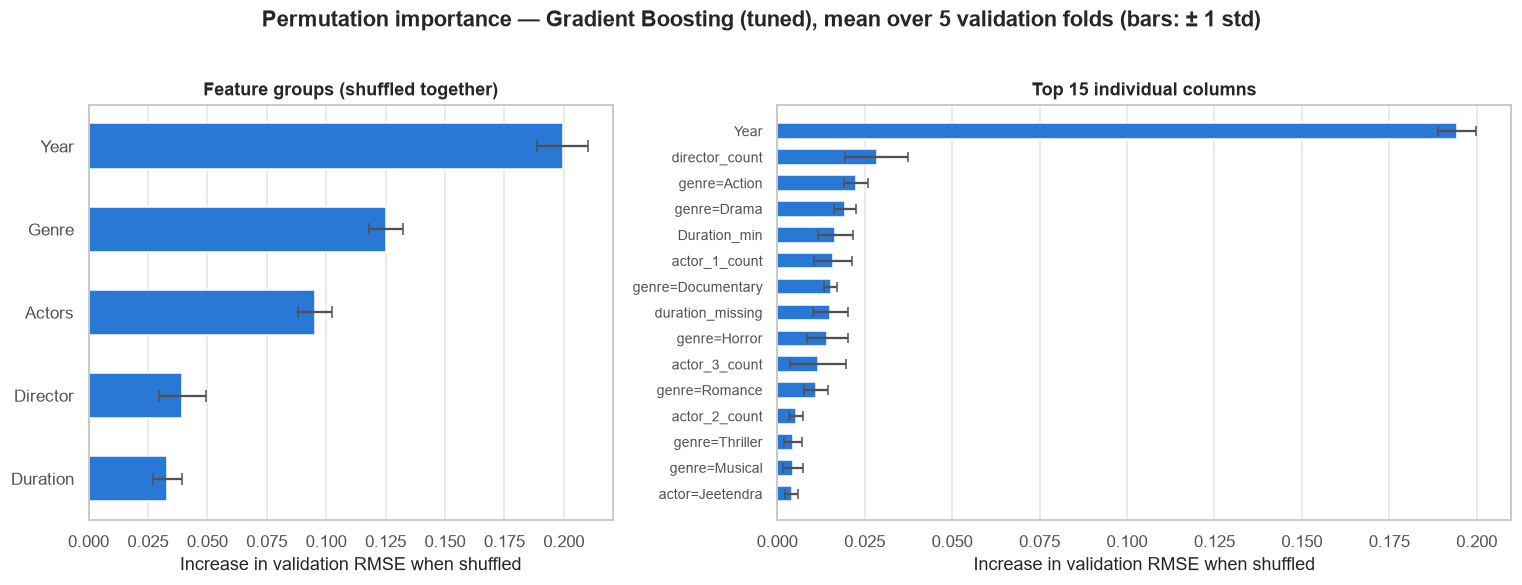

In [31]:
# 15_feature_importance.png
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.4]})
g = group_imp.iloc[::-1]
axes[0].barh(g.index, g["mean RMSE increase"], xerr=g["std across folds"], color=PRIMARY, height=0.55,
             error_kw={"ecolor": MUTED, "capsize": 4})
axes[0].set_title("Feature groups (shuffled together)")
axes[0].set_xlabel("Increase in validation RMSE when shuffled")
axes[0].grid(axis="y", visible=False)

t = top_features.head(15).iloc[::-1]
axes[1].barh(t.index, t["mean RMSE increase"], xerr=t["std across folds"], color=PRIMARY, height=0.6,
             error_kw={"ecolor": MUTED, "capsize": 3})
axes[1].set_title("Top 15 individual columns")
axes[1].set_xlabel("Increase in validation RMSE when shuffled")
axes[1].tick_params(axis="y", labelsize=9)
axes[1].grid(axis="y", visible=False)
fig.suptitle(f"Permutation importance — {ANALYSIS_MODEL_NAME}, mean over {N_FOLDS} validation folds (bars: ± 1 std)",
             fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "15_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 18. Prediction Range Analysis

Phase 3 found predictions compressed toward the middle of the scale. Here the analysis uses **out-of-fold (OOF)**
predictions: every development film is predicted exactly once, by the model from the fold where it was in
validation. Rating bands are **Low** (< 4), **Mid** (4 to < 7) and **High** (≥ 7).

In [32]:
RANGE_MODELS = ["Baseline (fold-train mean)", "Linear Regression", "Random Forest", "Gradient Boosting",
                "Random Forest (tuned)", "Gradient Boosting (tuned)"]
DIAG["12 OOF predictions complete (each development row predicted once)"] = all(
    CV_RUNS[m]["oof"].notna().all() for m in RANGE_MODELS)

def dist_stats(s):
    return {"min": s.min(), "p5": s.quantile(0.05), "median": s.median(), "p95": s.quantile(0.95), "max": s.max(), "std": s.std()}

range_table = pd.DataFrame({"Actual rating": dist_stats(y_dev),
                            **{m: dist_stats(CV_RUNS[m]["oof"]) for m in RANGE_MODELS[1:]}}).T
range_table["p95 − p5 span"] = range_table["p95"] - range_table["p5"]
range_table.round(3)

,min,p5,median,p95,max,std,p95 − p5 span
Actual rating,1.100,3.300,6.000,7.900,10.000,1.379,4.600
Linear Regression,2.844,4.693,5.808,7.086,9.078,0.714,2.393
Random Forest,3.814,4.756,5.871,6.919,8.278,0.690,2.163
Gradient Boosting,3.772,4.791,5.828,6.820,8.442,0.644,2.029
Random Forest (tuned),3.814,4.756,5.871,6.919,8.278,0.690,2.163
Gradient Boosting (tuned),3.529,4.569,5.865,7.087,9.326,0.793,2.518


In [33]:
band = pd.cut(y_dev, bins=[-np.inf, 4, 7, np.inf], right=False, labels=["Low (<4)", "Mid (4–7)", "High (≥7)"])
band_rows = []
for m in RANGE_MODELS:
    res = y_dev - CV_RUNS[m]["oof"]
    for b in band.cat.categories:
        mask = band == b
        band_rows.append({"model": m, "band": b, "films": int(mask.sum()), "MAE": res[mask].abs().mean(),
                          "RMSE": float(np.sqrt((res[mask] ** 2).mean())), "mean residual": res[mask].mean()})
band_table = pd.DataFrame(band_rows)
band_table.pivot(index="model", columns="band", values=["MAE", "mean residual"]).loc[RANGE_MODELS].round(3)

MAE                    mean residual                   
band                       High (≥7) Low (<4) Mid (4–7)     High (≥7) Low (<4) Mid (4–7)
model                                                                                   
Baseline (fold-train mean)     1.723    2.553     0.703         1.723   -2.553    -0.158
Linear Regression              1.309    2.071     0.674         1.265   -2.069    -0.080
Random Forest                  1.241    2.016     0.637         1.232   -2.016    -0.106
Gradient Boosting              1.276    2.056     0.626         1.269   -2.056    -0.102
Random Forest (tuned)          1.241    2.016     0.637         1.232   -2.016    -0.106
Gradient Boosting (tuned)      1.155    1.913     0.658         1.129   -1.913    -0.098

In [34]:
print("Films per band (development set):", band.value_counts().reindex(band.cat.categories).to_dict())
band_table.pivot(index="model", columns="band", values="RMSE").loc[RANGE_MODELS].round(3)

Films per band (development set): {'Low (<4)': 676, 'Mid (4–7)': 4267, 'High (≥7)': 1392}


band,High (≥7),Low (<4),Mid (4–7)
model,,,
Baseline (fold-train mean),1.794,2.605,0.837
Linear Regression,1.516,2.203,0.839
Random Forest,1.425,2.157,0.803
Gradient Boosting,1.449,2.184,0.784
Random Forest (tuned),1.425,2.157,0.803
Gradient Boosting (tuned),1.360,2.087,0.830


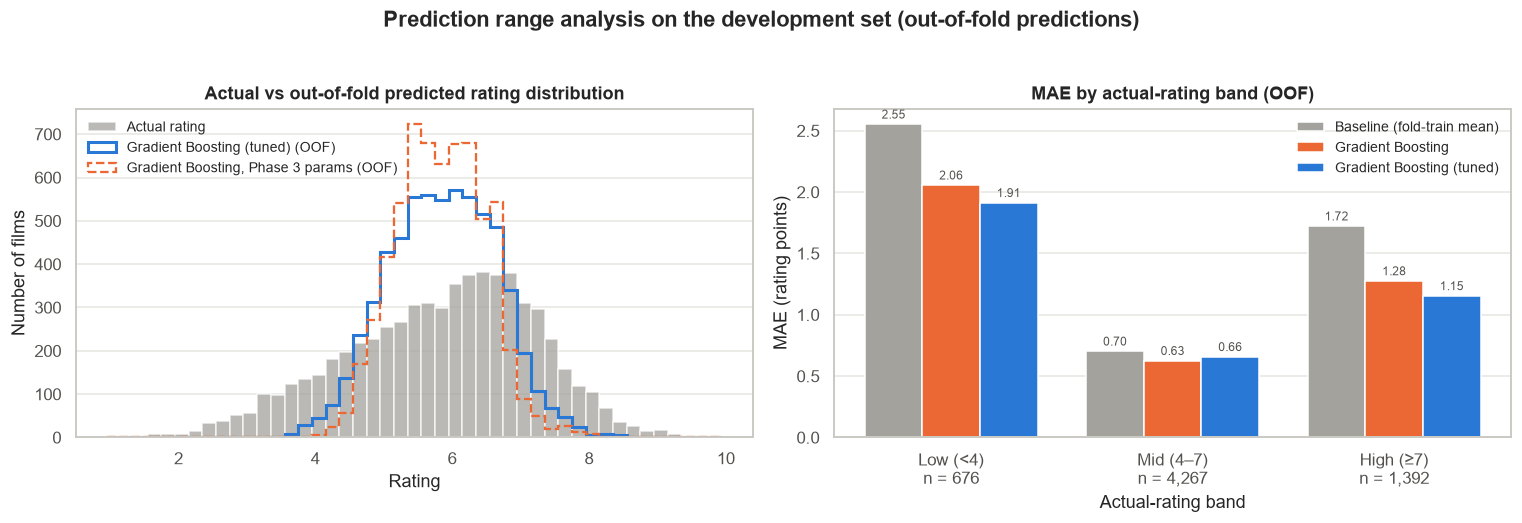

In [35]:
# 16_prediction_range_analysis.png
cand_oof = CV_RUNS[ANALYSIS_MODEL_NAME]["oof"]
p3_name = "Gradient Boosting"
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
bins = np.arange(0.95, 10.15, 0.2)
axes[0].hist(y_dev, bins=bins, color=NEUTRAL, alpha=0.75, label="Actual rating")
axes[0].hist(cand_oof, bins=bins, histtype="step", linewidth=2, color=PRIMARY, label=f"{ANALYSIS_MODEL_NAME} (OOF)")
axes[0].hist(CV_RUNS[p3_name]["oof"], bins=bins, histtype="step", linewidth=1.5, linestyle="--", color=ACCENT,
             label=f"{p3_name}, Phase 3 params (OOF)")
axes[0].set_title("Actual vs out-of-fold predicted rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of films")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
axes[0].grid(axis="x", visible=False)

show = ["Baseline (fold-train mean)", p3_name, ANALYSIS_MODEL_NAME]
colors = [NEUTRAL, ACCENT, PRIMARY]
bands = list(band.cat.categories)
w = 0.26
for i, (m, c) in enumerate(zip(show, colors)):
    vals = band_table[band_table["model"] == m].set_index("band").loc[bands, "MAE"]
    bars = axes[1].bar(np.arange(len(bands)) + (i - 1) * w, vals, width=w, color=c, label=m)
    axes[1].bar_label(bars, labels=[f"{v:.2f}" for v in vals], padding=2, fontsize=8, color=MUTED)
counts = band.value_counts().reindex(bands)
axes[1].set_xticks(range(len(bands)))
axes[1].set_xticklabels([f"{b}\nn = {counts[b]:,}" for b in bands])
axes[1].set_title("MAE by actual-rating band (OOF)")
axes[1].set_ylabel("MAE (rating points)")
axes[1].set_xlabel("Actual-rating band")
axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(axis="x", visible=False)
fig.suptitle("Prediction range analysis on the development set (out-of-fold predictions)", fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "16_prediction_range_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## 19. Error Analysis

These are the largest out-of-fold errors of the analysis model, with context taken from the modeling dataframe.
`Votes` is attached **for diagnosis only**; it is not a model input.

In [36]:
dev_rows = model_df.loc[X_dev.index]
oof_err = pd.DataFrame({
    "Name": dev_rows["Name"], "Year": dev_rows["Year"].astype("Int64"), "Genre": dev_rows["Genre"],
    "Director": dev_rows["Director"], "Actual": y_dev, "Predicted (OOF)": cand_oof,
    "Residual": y_dev - cand_oof, "Duration_min": dev_rows["Duration_min"],
    "Votes (diagnostic)": dev_rows["Votes_eda"],
})
oof_err["Absolute Error"] = oof_err["Residual"].abs()
oof_err = oof_err.sort_values("Absolute Error", ascending=False)
oof_err.head(15).round(2)

,Name,Year,Genre,Director,Actual,Predicted (OOF),Residual,Duration_min,Votes (diagnostic),Absolute Error
2756,Gul Makai,2020,"Biography, Drama, War",Amjad Khan,2.4,7.11,-4.71,132.0,213.0,4.71
2237,Dus,1997,Action,Mukul Anand,9.1,4.43,4.67,<NA>,44.0,4.67
7663,Welcome to New York,2018,"Comedy, Drama",Chakri Toleti,1.6,6.14,-4.54,118.0,774.0,4.54
6344,Sanjeevani,2018,Drama,Ravi Vide,2.8,7.27,-4.47,<NA>,23.0,4.47
5675,Prem Aggan,1998,"Drama, Romance",Feroz Khan,1.7,6.15,-4.45,168.0,544.0,4.45
819,B.A. Pass 2,2017,Drama,Shadab Khan,2.1,6.40,-4.30,125.0,419.0,4.30
959,Bal Ganesh and the PomZom Planet,2017,Animation,Vijay S. Bhanushali,2.3,6.53,-4.23,81.0,9.0,4.23
3168,I'm in Love,2007,Action,Tom Alter,9.2,5.03,4.17,140.0,36.0,4.17
6904,Super Model,2013,"Drama, Mystery, Romance",Navin Batra,1.9,6.01,-4.11,83.0,180.0,4.11
2995,Himmatwala,2013,"Action, Comedy, Drama",Sajid Khan,1.7,5.79,-4.09,150.0,8186.0,4.09


In [37]:
top = oof_err["Absolute Error"] >= oof_err["Absolute Error"].quantile(0.9)
director_train_counts = pd.Series(np.nan, index=X_dev.index)
for f in analysis_folds:   # director count as seen by the fold's own fitted transformer
    director_train_counts.iloc[f["va"]] = f["Xt_va"]["director_count"].to_numpy()
oof_err["director_train_films"] = director_train_counts

def profile(fr):
    return pd.Series({
        "films": len(fr),
        "share actual < 4 or ≥ 8.5": (fr["Actual"].lt(4) | fr["Actual"].ge(8.5)).mean(),
        "share over-predicted (residual < 0)": fr["Residual"].lt(0).mean(),
        "share duration missing": fr["Duration_min"].isna().mean(),
        "share director unseen in fold-train": fr["director_train_films"].eq(0).mean(),
        "median votes (diagnostic)": fr["Votes (diagnostic)"].median(),
    })
pd.DataFrame({"top 10% OOF errors": profile(oof_err[top]), "other 90%": profile(oof_err[~top])}).round(3)

,top 10% OOF errors,other 90%
films,634.000,5701.000
share actual < 4 or ≥ 8.5,0.563,0.071
share over-predicted (residual < 0),0.614,0.469
share duration missing,0.248,0.267
share director unseen in fold-train,0.383,0.290
median votes (diagnostic),101.500,53.000


The profile table is read the same way as in Phase 3: **observed patterns and hypotheses**, not causes. The
interpretation is in the summary (Section 23).

## 20. Phase 3 vs Phase 4 Comparison

The two kinds of number answer **different questions**:

- **Phase 3 (single holdout test):** how each model trained on the full development set scored on one fixed set of
  1,584 unseen films. It is one measurement, with no spread.
- **Phase 4 (5-fold group CV on the development set):** the average and variability of performance across five
  different validation splits, each model trained on 80% of the development set. It **never touched** the Phase 3
  test films.

They are shown side by side for context, not as the same measurement. The Phase 3 figures are **read from the saved
outputs of `03_model_training.ipynb`**, not recomputed, because recomputing them would require using the holdout.

In [38]:
import nbformat
nb3 = nbformat.read(PHASE3_NOTEBOOK, as_version=4)
phase3_text = "\n".join(o.get("text", "") for c in nb3.cells if c.cell_type == "code" for o in c.outputs)
phase3 = {}
for name in ["Gradient Boosting", "Random Forest", "Linear Regression", "Baseline (train mean)"]:
    m = re.search(re.escape(name) + r"\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)", phase3_text)
    if m:
        phase3[name] = dict(zip(["MAE", "MSE", "RMSE", "R²"], map(float, m.groups())))
DIAG["13 Phase 3 reference metrics read from saved notebook output (holdout not recomputed)"] = len(phase3) == 4

name_map = {"Baseline (train mean)": "Baseline (fold-train mean)"}
comparison = pd.DataFrame({
    "Phase 3 holdout TEST RMSE (single split)": {name_map.get(k, k): v["RMSE"] for k, v in phase3.items()},
    "Phase 4 CV RMSE mean (dev set)": full_summary["RMSE mean"],
    "Phase 4 CV RMSE std": full_summary["RMSE std"],
    "Phase 3 holdout TEST R²": {name_map.get(k, k): v["R²"] for k, v in phase3.items()},
    "Phase 4 CV R² mean": full_summary["R² mean"],
}).loc[ALL_MODELS]
comparison.round(4)

,Phase 3 holdout TEST RMSE (single split),Phase 4 CV RMSE mean (dev set),Phase 4 CV RMSE std,Phase 3 holdout TEST R²,Phase 4 CV R² mean
Baseline (fold-train mean),1.3914,1.3794,0.0318,-0.0008,-0.0016
Linear Regression,1.2197,1.2232,0.0237,0.2311,0.2123
Random Forest,1.1832,1.1733,0.0344,0.2764,0.2755
Gradient Boosting,1.1791,1.1761,0.0318,0.2813,0.2720
Random Forest (tuned),NaN,1.1733,0.0344,NaN,0.2755
Gradient Boosting (tuned),NaN,1.1549,0.0363,NaN,0.2980


Tuned models have no Phase 3 value because they did not exist then, and **they will not be scored on the holdout
until Phase 5**.

## 21. Final Candidate Selection

In [39]:
selection = full_summary.drop(index="Baseline (fold-train mean)")[
    ["RMSE mean", "RMSE std", "MAE mean", "R² mean", "train RMSE mean", "train−val RMSE gap"]].copy()
selection["folds beaten by reference"] = [
    np.nan if n == ref_all else int(paired_all.loc[n, "folds where model is worse"]) for n in selection.index]
selection["mean RMSE diff vs reference"] = [0.0 if n == ref_all else paired_all.loc[n, f"mean RMSE diff vs {ref_all}"]
                                            for n in selection.index]
selection["std of fold diffs"] = [np.nan if n == ref_all else paired_all.loc[n, "std of fold diffs"] for n in selection.index]
selection.round(4)

,RMSE mean,RMSE std,MAE mean,R² mean,train RMSE mean,train−val RMSE gap,folds beaten by reference,mean RMSE diff vs reference,std of fold diffs
model,,,,,,,,,
Gradient Boosting (tuned),1.1549,0.0363,0.9009,0.2980,0.9915,0.1634,NaN,0.0000,NaN
Random Forest,1.1733,0.0344,0.9167,0.2755,0.7904,0.3828,5.0,0.0184,0.0067
Random Forest (tuned),1.1733,0.0344,0.9167,0.2755,0.7904,0.3828,5.0,0.0184,0.0067
Gradient Boosting,1.1761,0.0318,0.9213,0.2720,1.1045,0.0716,5.0,0.0212,0.0072
Linear Regression,1.2232,0.0237,0.9624,0.2123,1.1778,0.0454,5.0,0.0683,0.0156


In [40]:
# "Effectively tied" rule: a model is not considered separable from the reference when the mean
# per-fold RMSE difference is smaller than the fold-to-fold standard deviation of that difference,
# or when the reference does not win on at least 4 of 5 folds.
def is_tied(n):
    if n == ref_all:
        return True
    row = paired_all.loc[n]
    return abs(row[f"mean RMSE diff vs {ref_all}"]) < row["std of fold diffs"] or row["folds where model is worse"] < 4

selection["tied with reference"] = [is_tied(n) for n in selection.index]
tied_set = selection.index[selection["tied with reference"]].tolist()
print(f"Reference (lowest mean CV RMSE): {ref_all}")
print(f"Models effectively tied with it: {tied_set}")
selection[["RMSE mean", "RMSE std", "train−val RMSE gap", "tied with reference"]].round(4)

Reference (lowest mean CV RMSE): Gradient Boosting (tuned)
Models effectively tied with it: ['Gradient Boosting (tuned)']


,RMSE mean,RMSE std,train−val RMSE gap,tied with reference
model,,,,
Gradient Boosting (tuned),1.1549,0.0363,0.1634,True
Random Forest,1.1733,0.0344,0.3828,False
Random Forest (tuned),1.1733,0.0344,0.3828,False
Gradient Boosting,1.1761,0.0318,0.0716,False
Linear Regression,1.2232,0.0237,0.0454,False


The candidate choice weighs the full CV evidence: mean RMSE and MAE, fold-to-fold stability, consistency of the
per-fold wins, train/validation gap (overfitting) and complexity. It does not rely on the lowest single metric. The
reasoning and the selected configuration are in the **Final candidate for Phase 5** part of Section 23.

## 22. Diagnostics

In [41]:
fc = pd.DataFrame(FOLD_CHECKS)
leak_cols = [c for c in fc.columns if "fold-train only" in c or "absent" in c]
DIAG["14 Preprocessing fitted on fold-train only (every fold, every configuration)"] = bool(
    fc[leak_cols].fillna(True).astype(bool).all().all())
DIAG["15 No NaN in any transformed fold matrix"] = bool(fc["no NaN"].all())
DIAG["16 No infinite values in any transformed fold matrix"] = bool(fc["no inf"].all())
DIAG["17 Train/validation feature columns match in every fold"] = bool(fc["columns match"].all())

every_run = list(CV_RUNS.values()) + list(ablation_runs.values()) + list(threshold_runs.values())
DIAG["18 Prediction lengths match validation targets (all runs)"] = all(
    r["oof"].notna().sum() == len(X_dev) for r in every_run)
DIAG["19 All CV metrics finite"] = all(np.isfinite(r["per_fold"][["MAE", "MSE", "RMSE", "R²"]].to_numpy()).all() for r in every_run)
DIAG["20 Ablation and threshold experiments use the identical fold assignment"] = all(
    r["fold_signature"] == FOLD_SIGNATURE and len(r["per_fold"]) == N_FOLDS for r in every_run)
DIAG["21 No holdout row appears in any fold"] = not set(X_dev.index[all_val]) & set(HOLDOUT_INDEX)

refit = clone(ANALYSIS_MODEL).fit(analysis_folds[0]["Xt_tr"], y_dev.iloc[analysis_folds[0]["tr"]])
DIAG["22 Refit on fold 1 reproduces identical predictions (determinism)"] = np.array_equal(
    refit.predict(analysis_folds[0]["Xt_va"]), analysis_run["models"][0].predict(analysis_folds[0]["Xt_va"]))
DIAG["23 Raw CSV unchanged (SHA-256 matches Phase 1)"] = file_sha256(DATA_PATH) == PHASE1_SHA256

print(f"Fold-level preprocessing checks performed: {len(fc)} (configs × folds)")
diag = pd.Series(DIAG, name="passed").sort_index().to_frame()
assert diag["passed"].all(), diag[~diag["passed"]]
print(f"{int(diag['passed'].sum())} / {len(diag)} diagnostics passed")
diag

Fold-level preprocessing checks performed: 40 (configs × folds)
23 / 23 diagnostics passed


,passed
01 Target not among feature inputs,True
02 Votes absent from primary feature inputs,True
"03 Phase 3 split reproduced (6,335 / 1,584 rows; 6,332 / 1,584 groups)",True
04 Holdout groups disjoint from development groups,True
05 No group overlap in any CV fold,True
06 Fold count correct and every development row validated exactly once,True
07 Baseline uses each fold's training mean (not a global mean),True
08 Manual fold loop reproduces sklearn Pipeline cross_validate,True
09 Hyperparameter search used the same group-aware folds (GroupKFold with groups),True
10 Search fitted on development rows only (no holdout rows),True


## 23. Phase 4 Summary

In [42]:
shutil.rmtree(CACHE_DIR, ignore_errors=True)   # temporary preprocessing cache; no models are saved

print("CV STRATEGY: GroupKFold(n_splits=5, shuffle=True, random_state=42) on the 6,335-row development set")
print(fold_table.to_string())
print("\nCV RESULTS (mean ± std over 5 folds):")
for n, r in full_summary.iterrows():
    print(f"  {n:<28} RMSE {r['RMSE mean']:.4f} ± {r['RMSE std']:.4f} | MAE {r['MAE mean']:.4f} ± {r['MAE std']:.4f} | "
          f"MSE {r['MSE mean']:.4f} ± {r['MSE std']:.4f} | R² {r['R² mean']:.4f} ± {r['R² std']:.4f} | train RMSE {r['train RMSE mean']:.4f}")
print("\nBest sampled configurations:", best_params)
print("Effectively tied with the reference:", tied_set)
print("\nAblation:", ablation_summary["RMSE mean"].round(4).to_dict())
print("Thresholds:", thr["RMSE mean"].round(4).to_dict())
print("Group importance:", group_imp["mean RMSE increase"].round(4).to_dict())
print(f"\nDiagnostics passed: {int(diag['passed'].sum())} / {len(diag)}")
print("Figures:", [f for f in ["12_cv_model_comparison.png", "13_cv_error_bars.png", "14_feature_group_ablation.png",
                               "15_feature_importance.png", "16_prediction_range_analysis.png"] if (FIG_DIR / f).exists()])
print(f"Notebook runtime: {(time.time() - NOTEBOOK_START) / 60:.1f} min")

CV STRATEGY: GroupKFold(n_splits=5, shuffle=True, random_state=42) on the 6,335-row development set
      training rows  validation rows  training groups  validation groups  group overlap
fold                                                                                   
1              5068             1267             5065               1267              0
2              5068             1267             5065               1267              0
3              5068             1267             5066               1266              0
4              5068             1267             5066               1266              0
5              5068             1267             5066               1266              0

CV RESULTS (mean ± std over 5 folds):
  Gradient Boosting (tuned)    RMSE 1.1549 ± 0.0363 | MAE 0.9009 ± 0.0256 | MSE 1.3348 ± 0.0845 | R² 0.2980 ± 0.0126 | train RMSE 0.9915
  Random Forest                RMSE 1.1733 ± 0.0344 | MAE 0.9167 ± 0.0233 | MSE 1.3775 ± 0.0813 | R² 0.2755 

### Findings (all numbers are 5-fold group-CV means ± std on the development set, from the outputs above)

**1. Phase 3 differences under cross-validation.** With the Phase 3 parameters, Random Forest (RMSE 1.173 ± 0.034)
and Gradient Boosting (1.176 ± 0.032) are **effectively tied**. The mean per-fold difference is 0.003, smaller than
its fold-to-fold standard deviation (0.005). The small Phase 3 lead of Gradient Boosting on the single holdout is
therefore not a stable difference. Both tree models beat Linear Regression (1.223) on every fold, and all models beat
the fold-train-mean baseline (1.379) on every fold.

**2. Tuning.**
- The best sampled Gradient Boosting configuration (`n_estimators=600, learning_rate=0.05, max_depth=4,
  min_samples_leaf=10, subsample=0.8`) reached **1.155 ± 0.036** RMSE, MAE 0.901 and R² 0.298. It was better than
  every other model **on all 5 folds**, with a mean advantage over Random Forest of 0.018, about 2.7× the
  fold-to-fold standard deviation of that difference.
- The best sampled Random Forest configuration is **identical to the Phase 3 parameters**, so tuning found no
  improvement for Random Forest within the searched space.
- Caveats: the Gradient Boosting score is slightly optimistic because it was selected on the same folds (no nested
  CV), and its best `n_estimators` and `max_depth` lie at the **upper edge** of the searched ranges.

**3. Feature groups (cumulative ablation, tuned Gradient Boosting).** RMSE fell at every step, and on every fold:

| Step | Mean ΔRMSE |
|---|---|
| Year + Duration → + Genre | −0.073 |
| + Director | −0.026 |
| + Actors | −0.029 |

Year + Duration alone reach R² ≈ 0.13; the full set reaches ≈ 0.30. Every feature group is associated with better
validation performance.

**4. Thresholds.**
- Changing the director threshold (5 / 10 / 20) changes RMSE by at most 0.004.
- Lowering the actor threshold to 10 improved RMSE by 0.008; raising it to 40 worsened it by 0.009.

These effects are small, under 1% of RMSE and well inside the fold-to-fold spread of about 0.036. The Phase 2 defaults
(10 / 20) are therefore **kept**. Switching to actor ≥ 10 would be another choice made on the same folds, for a gain
that is not material.

**5. Importance (permutation, validation folds).** When shuffled, the groups raise RMSE in this order:
**Year** (+0.20) > **Genre** (+0.13) > **Actors** (+0.10) > **Director** (+0.04) > **Duration** (+0.03). The single most
influential column is `Year`, followed by `director_count`, several genre indicators, `Duration_min`,
`duration_missing` and the actor count features. The impurity-based view ranks Actors slightly above Year. That
measure favours features with many split points (such as the actor count columns) and is computed on training data,
so the permutation ranking on validation folds is the primary one. Both views describe what the model relies on for
prediction, **not** causes of ratings.

**6. Prediction range.**
- Tuned Gradient Boosting widens the out-of-fold predictions: std 0.79 vs 0.64 for the Phase 3 Gradient Boosting
  configuration, and the 5–95% span grows from 2.03 to 2.52 rating points.
- It reduces MAE for **low-rated** films (< 4: 2.06 → 1.91, n = 676) and **high-rated** films (≥ 7: 1.28 → 1.16,
  n = 1,392), at a small cost for mid-range films (0.63 → 0.66).

The extreme-rating problem is **reduced but far from solved**. The actual 5–95% span is 4.6 points, predictions remain
strongly compressed, and 56% of the largest 10% of errors are films rated below 4 or at least 8.5.

**7. Overfitting.**
- Random Forest (Phase 3 parameters): train RMSE 0.79 vs validation 1.17, a gap of 0.38. It memorises much of the
  training data.
- Tuned Gradient Boosting: gap 0.16.
- Phase 3 Gradient Boosting: gap 0.07.
- Linear Regression: gap 0.05.

The tuned model gains validation accuracy at the price of a larger, but still moderate, train/validation gap.

### Final candidate for Phase 5

**Gradient Boosting (tuned):** `n_estimators=600, learning_rate=0.05, max_depth=4, min_samples_leaf=10,
subsample=0.8, random_state=42`, with the full primary feature set and the Phase 2 thresholds (director ≥ 10,
actor ≥ 20).

Evidence:
- lowest mean CV RMSE and MAE, and highest R²
- better than every other model on all 5 folds, by more than the fold-to-fold noise
- fold-to-fold variability similar to the other tree models (std 0.036 vs 0.032–0.034)
- a much smaller overfitting gap than Random Forest
- reduced error at both rating extremes

It is more complex than the Phase 3 configuration (600 trees of depth 4). The simpler **Gradient Boosting with Phase 3
parameters** is the recommended **reference model** for Phase 5, so the holdout can show whether the tuning gain
survives on unseen data.

### Limitations and unexpected findings

1. The tuned score is selected and evaluated on the same folds, so it is mildly optimistic. The Phase 3 holdout will
   give the unbiased estimate.
2. Two tuned values lie at the edge of the search space (`n_estimators=600`, `max_depth=4`). A wider search was not
   run, to keep tuning controlled.
3. The search was small: 12 Gradient Boosting and 10 Random Forest sampled configurations, one factor at a time for
   the thresholds, and thresholds were not re-tuned jointly with model parameters.
4. Unexpected: Random Forest tuning did not improve on the Phase 3 parameters. Year is by far the most influential
   feature group, ahead of director and actor information.
5. Even the best model explains only about 30% of the rating variance in CV. Metadata alone leaves most of the
   variation unexplained.
6. `Votes` was not investigated. The optional secondary experiment remains open and would not replace these primary
   results.

*The Phase 3 holdout test set was not used, no model was saved to disk, and the raw CSV was not modified.*